## 1. Preprocess danish data

In [61]:
import pandas as pd
import seaborn as sns

df_danmark_man = pd.read_csv('Leiden_20240401_denmark.csv', sep=';')

l_num = ['PATNR', 'Age', 'BSE', 'Hb', 'MCV', 'Trom', 'Leuko'] # no 'Ht', 
l_essential = ['PATNR', 'Age', 'Sex', 'aCCP', 'RF', 'BSE', 'Hb', 'MCV', 'Trom', 'Leuko', 'SJC', 'TJC', 'FirstConsult'] # no 'Ht',  

df_danmark_man = df_danmark_man.rename(columns= {'patientprojectnumbernordstar' : 'PATNR'})
#df = df.rename(columns= d_map)
print(len(df_danmark_man['PATNR'].unique()))

198


#### remap icelandic patients
In iceland we need to select SubjectID instead of patientprojectnumbernordstar. This is because in Iceland, each patient had one id number starting with 90 and one id number starting with 91.

In [62]:
d_remap_icelandic = dict(zip(df_danmark_man[df_danmark_man['PATNR']!=df_danmark_man['SubjectId']]['PATNR'], df_danmark_man[df_danmark_man['PATNR']!=df_danmark_man['SubjectId']]['SubjectId']))

In [64]:
df_danmark_man['PATNR'] = df_danmark_man['PATNR'].apply(lambda x : d_remap_icelandic[x] if x in d_remap_icelandic.keys() else x)

### 1.1 Format mannequin data (to align w/ Leiden)

In [55]:
import re 

def convert_Danmark_name_Mannequin(col_name):
    """
    Standardize the data by converting the name of a Nordstar (Danish) variable to the HIX equivalent
    
    Input:
        col_name = initial column name
    Return: 
        new_col = updated column name
    """
    new_col = ""
    d_swollen = {'GZ' : 'Zwelling_', 'GP': 'Pijn_'}
    d_side = {'L': 'links', 'R' : 'rechts'} # 
    d_side_alt = {'L': 'L', 'R' : 'R'}
    
    d_entity = {'ACC': 'acromioclaviaculair', 'ANCLE': 'bovenste spronggewricht', 'STAL': 'onderste spronggewricht', 'ELBOW' : 'Elleboog', 'IP' : 'IP', 'FIP' : 'FIP', 'KNEE' : 'knie', 'MCP' : 'mcp', 'TARS' : 'tarsometatarsaal', 'MTP' : 'mtp', 'PIP' : 'pip', 'CHEST' : 'sternoclaviculair', 'SHOULDER' : 'schouder', 'CHICK' : 'temporomandibulair', 'WRIST' : 'pols','PIP' : 'pip', 'FPIP' : 'pip', 'DIP' : 'dip', 
                'HIP' : 'heup', 'NECK' : 'cervical spine'} # Or is it PIP
    if col_name[0:2] in d_swollen and col_name[-1] in d_side:
        #print(col_name[0:2], col_name[-1])
        # extract specific joint
        joint = re.search("^(" + "|".join(d_entity.keys())+ ")$", ''.join([i for i in col_name[2:-1] if not i.isdigit()]))
        #print(joint)
        if joint and '28' not in col_name:
            new_col += d_swollen[col_name[0:2]]
            
            # Account for exceptions
            if joint[0] == 'ELBOW' and col_name[-1]=='R' :
                entity = d_entity[joint[0]].lower()
            elif  joint[0] == 'ANCLE' and col_name[-1]=='L':
                entity = 'bovenste spronggewicht' 
            elif joint[0] == 'FPIP' :
                if col_name[-2].isdigit():
                    entity = 'pip'
            elif joint[0] == 'FIP':
                    entity = 'IP'
            else : 
                entity = d_entity[joint[0]]
            
            new_col += entity
            
            if col_name[-2].isdigit() and joint[0] != 'FIP': # note specific joint
                new_col += " " + col_name[-2]
            if joint[0] in ['ELBOW', 'SHOULDER', 'WRIST', 'CHEST', 'ACC', 'TARS', 'CHICK']:
                new_col += " " + d_side_alt[col_name[-1]]  
            elif joint[0] in ['PIP'] :
                new_col += " " + d_side[col_name[-1]] + " hand"
            elif joint[0] in ['FIP']:
                new_col += " voet " + d_side[col_name[-1]]
            elif joint[0] in ['FPIP'] :
                new_col += " " + d_side[col_name[-1]] + " voet"
            elif joint[0] in ['NECK']:
                pass
                
            else :
                new_col += " " + d_side[col_name[-1]]
        return new_col, True
    else : 
        return col_name, False
                 
# is vip pip
# ToDo ; Add Cervicular = NECK cervical spine_
# ToDO; Add footpip -> FPIP ('Pijn_pip 4 rechts voet_negative)
# DAS joints are : enkel (spronggewricht / spronggewicht), Elleboog/elleboog, heup, ip, knie,  mcp, mtp, pip,  schouder,  pols,  
l_das_joints = ['ACC', 'ANCLE','STAL', 'ELBOW', 'IP', 'KNEE', 'MCP', 'TARS', 'MTP', 'PIP', 'FPIP', 'CHEST', 'SHOULDER',  'CHICK', 'WRIST', 'FIP', 'DIP', 'HIP', 'NECK']              
d_joint = {}

for joint in l_das_joints:
    for col in df_danmark_man.columns :
        #print(col)
        new_col = col.replace('nordstar_nordstar66swollenjoints_', 'GZ').replace('nordstar_nordstar68tenderjoints_', 'GP').replace('_', '')
        if joint in new_col and convert_Danmark_name_Mannequin(new_col)[1]:
            if convert_Danmark_name_Mannequin(new_col)[0] not in d_joint.values(): # prevent duplicates
                d_joint[col] = convert_Danmark_name_Mannequin(new_col)[0]

            
# Translate 
l_joints = list(d_joint.values())
df_danmark_man= df_danmark_man.rename(columns = d_joint)
df_danmark_man = df_danmark_man.loc[:, ~df_danmark_man.columns.duplicated()]

# Keep only screening visits
df_danmark_man = df_danmark_man[df_danmark_man['nordstar_nordstarvisitnumber']=='nordstar_visit_screening'].reset_index(drop=True)
#df_danmark

### 1.2 Cast categorical data to one hot encoding

In [56]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler # Z-score
from sklearn.preprocessing import RobustScaler  # Robust Z-score
from sklearn.preprocessing import PowerTransformer # Yeo-Johnson
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
import numpy as np
import pandas as pd

l_categorical = ['PATNR'] # , 'RF', 'aCCP', 'Sex', 'Age_Early', 'Age_Late'
l_joints = [ i for i in list(d_joint.values()) if i != '']

l_categorical.extend(l_joints)

new_df = df_danmark_man[l_categorical].copy()


# Perform OHE
def cast_to_one_hot(values):
    label_encoder = LabelEncoder()
    integer_encoded = label_encoder.fit_transform(values)

    onehot_encoder = OneHotEncoder(sparse=False)
    integer_encoded = integer_encoded.reshape(len(integer_encoded), 1)
    onehot_encoded = onehot_encoder.fit_transform(integer_encoded)
    df = pd.DataFrame(onehot_encoded, columns=[0, 1])
    df.index = np.arange(0, len(df))
    return df[0], df[1]

for cat in l_joints:
    # Easy fix: Cap at 1 
    #print(new_df[cat])
    if len(new_df[cat].unique())> 2:
        print('Headsup: there are more than 2 possibilities for column "%s" which is supposed to be binary, namely: %s' % (cat, str(new_df[cat].unique())))
    new_df[cat] = new_df[cat].apply(lambda x: 1 if x in [1,2,3] else 0) # This implies that if it is missing it will also be recorded as 0
    # If the column is non-informative
    if len(new_df[cat].unique()) == 1:
        if new_df[cat].iloc[0] == 0:
            new_df['%s_negative' % (cat)], new_df['%s_positive' % (cat)] = 1, 0
        else : 
            new_df['%s_negative' % (cat)], new_df['%s_positive' % (cat)] = 0, 1
        new_df = new_df.drop(columns=cat)
    else :
        new_df['%s_negative' % (cat)], new_df['%s_positive' % (cat)] = cast_to_one_hot(new_df[cat].values)
        new_df = new_df.drop(columns=cat)


Headsup: there are more than 2 possibilities for column "Zwelling_bovenste spronggewricht rechts" which is supposed to be binary, namely: [ 0.  1. nan]
Headsup: there are more than 2 possibilities for column "Zwelling_bovenste spronggewicht links" which is supposed to be binary, namely: [ 0.  1. nan]
Headsup: there are more than 2 possibilities for column "Pijn_bovenste spronggewricht rechts" which is supposed to be binary, namely: [ 0.  1. nan]
Headsup: there are more than 2 possibilities for column "Pijn_bovenste spronggewicht links" which is supposed to be binary, namely: [ 0.  1. nan]
Headsup: there are more than 2 possibilities for column "Zwelling_elleboog R" which is supposed to be binary, namely: [ 0.  1. nan]
Headsup: there are more than 2 possibilities for column "Zwelling_Elleboog L" which is supposed to be binary, namely: [ 0.  1. nan]
Headsup: there are more than 2 possibilities for column "Pijn_elleboog R" which is supposed to be binary, namely: [ 0.  1. nan]
Headsup: the

/tmp/ipykernel_109046/3906233433.py:44: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  new_df['%s_negative' % (cat)], new_df['%s_positive' % (cat)] = cast_to_one_hot(new_df[cat].values)
/tmp/ipykernel_109046/3906233433.py:44: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  new_df['%s_negative' % (cat)], new_df['%s_positive' % (cat)] = cast_to_one_hot(new_df[cat].values)
/tmp/ipykernel_109046/3906233433.py:44: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which 

### 1.3.1 Check missing

In [57]:
df_categoric = pd.read_csv('../../../new_data/5_clustering/df_categoric_wAge.csv', sep=',')
l_cat_shared = list(df_categoric[[col for col in df_categoric.columns if col in new_df.columns]].columns)
l_cat_shared.append('pseudoId')
l_cat_patnr =  l_cat_shared[:-1]
l_cat_patnr.append('PATNR')

pd.DataFrame({'Columns': l_cat_shared}).to_csv('Danmark/Danmark_columns_cat.csv', sep='|', index=False)

# Show missing variables
l_exclude = list(set(df_categoric.columns) - set(new_df.columns))
print('Missing variables:', l_exclude)

Missing variables: ['Pijn_dip 2 rechts voet_positive', 'Age_Early', 'Zwelling_acromioclaviaculair R_positive', 'Pijn_onderste spronggewricht links_positive', 'Zwelling_dip 3 rechts voet_positive', 'Pijn_cmc 1 rechts_negative', 'Zwelling_dip 2 links voet_positive', 'Zwelling_dip 2 rechts voet_negative', 'Pijn_dip 2 links voet_negative', 'Pijn_dip 3 rechts voet_negative', 'Pijn_Manubrio sternaal gewricht_positive', 'Pijn_sacro-ileacaal gewricht links_negative', 'RF', 'Pijn_dip 4 links voet_positive', 'Zwelling_heup rechts_negative', 'Zwelling_heup links_positive', 'Pijn_dip 4 rechts voet_negative', 'Zwelling_dip 2 links voet_negative', 'Zwelling_cmc 1 links_positive', 'Zwelling_dip 3 rechts voet_negative', 'Pijn_acromioclaviaculair L_positive', 'aCCP', 'Zwelling_dip 4 links voet_negative', 'Zwelling_onderste spronggewricht rechts_positive', 'Age_Late', 'Pijn_acromioclaviaculair R_negative', 'Zwelling_cmc 1 rechts_negative', 'Zwelling_cmc 1 links_negative', 'Sex', 'Pijn_dip 5 links voet_n

## 1.4 Get numeric features

In [39]:
df_danmark_num = pd.read_csv('Leiden_20240401.csv', sep=';')
df_danmark_num = df_danmark_num[df_danmark_num['CountryId'].isin(['DENMARK', 'ICELAND'])].reset_index(drop=True)
# 'Hb', 'MCV', 'Trom', 'Leuko',
l_essential = ['PATNR', 'Age', 'Sex', 'aCCP', 'RF', 'BSE', 'CRP', 'SJC', 'TJC'] # no 'Ht',  

# Convert the float to datetime
df_danmark_num['EventDate'] = df_danmark_num['EventDate'].astype(str).str.split('.').str[0]
df_danmark_num['EventDate'] = pd.to_datetime(df_danmark_num['EventDate'], format='%Y%m%d')

df_danmark_num = df_danmark_num.rename(columns= {'SubjectId' : 'PATNR', 'CALC_AGE' : 'Age', 'PATSEXCD' : 'Sex', 'CALC_BMI' : 'BMI', 'ANSRVAL' : 'BSE',
 'ANCRPVAL' : 'CRP', 'ANCCPRESCD' : 'aCCP', 'ANRFRESCD' : 'RF'})

# Drop duplicates, keep only baseline information
df_danmark_num = df_danmark_num[df_danmark_num['EventId']=='00_SCR']
#df_danmark_num = df_danmark_num.sort_values(by='EventDate').drop_duplicates(subset=['PATNR'], keep='first')
df_danmark_num[l_essential]

,PATNR,Age,Sex,aCCP,RF,BSE,CRP,SJC,TJC
0,4101,49.0,2.0,1.0,1.0,NaN,8.0,3.0,2.0
9,4102,50.0,1.0,1.0,1.0,NaN,8.0,9.0,2.0
18,4103,39.0,2.0,0.0,1.0,NaN,6.0,18.0,26.0
27,4104,34.0,2.0,1.0,1.0,NaN,14.0,9.0,27.0
36,4106,64.0,2.0,0.0,1.0,NaN,9.0,9.0,18.0
...,...,...,...,...,...,...,...,...,...
1737,9012,71.0,1.0,0.0,0.0,NaN,76.0,31.0,29.0
1746,9013,33.0,2.0,1.0,1.0,NaN,5.0,17.0,20.0
1755,9014,55.0,1.0,1.0,0.0,NaN,4.0,25.0,38.0
1764,9015,58.0,2.0,0.0,0.0,NaN,50.0,24.0,44.0


### Create categoric dataframe

In [ ]:
df_categoric = df_danmark_num[['PATNR', 'Sex', 'RF', 'aCCP']].merge(new_df, on='PATNR', how='left') # 'Age', 
df_categoric['Sex'] = df_categoric['Sex'] - 1
l_cat = df_categoric.columns

df_categoric.to_csv('Danmark/df_danmark_categoric_ohe.csv', sep='|', index=False)

### 1.5 Infer CRP based on ESR

In [ ]:
import pickle
import numpy as np
# Save the PolynomialFeatures and the LinearRegression model
with open('/exports/reum/tdmaarseveen/MTX_prediction/crp_model/Polyfit_CRP.pkl', 'rb') as f:
    loaded_poly = pickle.load(f)
with open('/exports/reum/tdmaarseveen/MTX_prediction/crp_model/Predict_ESR_with_CRP.pkl', 'rb') as f:
    loaded_model = pickle.load(f)
    
df_danmark_num = df_danmark_num.dropna(subset=['CRP'])
X_test_poly_loaded = loaded_poly.transform(df_danmark_num['CRP'].values.reshape(-1, 1))

df_danmark_num['BSE'] = loaded_model.predict(X_test_poly_loaded)
df_danmark_num[['CRP', 'BSE']]

## Export numeric

In [ ]:

def normalizeLab(df):
    """
    Input: 
        df = complete dataframe
    
    Description:
        This function processes the Lab data. 
        Categorical data is subjected to a one-hot-encoding
        while the numerical data is cast to a z-scale as normalization
        
        Furthermore, the ESR (or BSE in dutch) is subjected to a 
        log-transformation.
    
    Output:
        df_dummies = dataframe with preprocessed categorical data 
        df_b = dataframe with preprocessed numerical data
    """
    l_num = ['BSE', 'Age'] # 'Ht', 
    
    # Log transform the ESR data
    df['BSE'] = np.log(df['BSE'])
    
    ct = ColumnTransformer([("num", PowerTransformer(), l_num)], remainder="passthrough")
    df_num= pd.DataFrame(ct.fit_transform(df[l_num]), columns=l_num)
    return df_num.merge(df['PATNR'], left_index=True, right_index=True)

l_num = ['PATNR',  'BSE', 'Age'] # 'Ht', 

# Define df lab
df_lab= df_danmark_num[l_num].reset_index(drop=True).copy()

# Save lab data (unnormalized)
df_lab.to_csv(r'Danmark/Danmark_Lab_wide_unscaled.csv', sep='|', index=False)
print('Written to ../Danmark/Danmark_Lab_wide_unscaled.csv')

# Normalize lab values
df_lab_sc = normalizeLab(df_lab.copy())

# Save lab data (normalized)
df_lab_sc.to_csv(r'Danmark/Danmark_Lab_wide_scaled.csv', sep='|', index=False)
df_lab_sc.head()

print(len(df_lab_sc), len(df_lab_sc['PATNR'].unique()))

### Create baseline table

In [ ]:
import numpy as np

def IQR(data):
    # First quartile (Q1)
    Q1 = np.percentile(data, 25, interpolation = 'midpoint')

    # Third quartile (Q3)
    Q3 = np.percentile(data, 75, interpolation = 'midpoint')
   
    # Interquaritle range (IQR)
    iqr = Q3 - Q1
    return [Q1, Q3]

df_summary = pd.DataFrame(columns=['cluster', 'N', 'Sex, F [n(%)]','Age (median+-IQR)', 'RF [n(%)]', 'ACPA [n(%)]', 'CRP (median+-IQR)', 'DAS28 (median+-IQR)', 'SJC (median+-IQR)', 'TJC (median+-IQR)', 'RF_na [n(%)]','ACPA_na [n(%)]', 'ESR_na [n(%)]' , 'Mannequin_na [n(%)]']) #TreatSwitch [n(%)]', 

df_subset = df_danmark_num[((~df_danmark_num['Sex'].isna()) ) ].copy() #& (df_danmark_num['CountryId']=='ICELAND')
df_subset['Sex'] = df_subset['Sex'] -1
#df_subset['symptomDuration'] = df_subset['symptomDuration']*7 # give symptom duration in days

def generate_baseline_ref(df_baseline, name = 'All', frac=''):
    if frac != '' :
        frac = '(' + frac + ')'
    return [name, '%.0f %s' % (len(df_baseline), frac), 
     '%.0f (%.1f)' % (np.sum(df_baseline['Sex']), np.mean(df_baseline['Sex']) * 100), 
     '%.1f (%.1f-%.1f)' % (np.median(df_baseline[~df_baseline['Age'].isna()]['Age']), IQR(df_baseline[~df_baseline['Age'].isna()]['Age'])[0], IQR(df_baseline[~df_baseline['Age'].isna()]['Age'])[1]),
     '%.1f (%.1f)' % (np.sum(df_baseline[~df_baseline['RF'].isna()]['RF']), np.mean(df_baseline[~df_baseline['RF'].isna()]['RF']) * 100), 
     '%.1f (%.1f)' % (np.sum(df_baseline[~df_baseline['aCCP'].isna()]['aCCP']), np.mean(df_baseline[~df_baseline['aCCP'].isna()]['aCCP']) * 100), 
       
     '%.1f (%.1f-%.1f)' % (np.median(df_baseline[~df_baseline['BSE'].isna()]['BSE']), IQR(df_baseline[~df_baseline['BSE'].isna()]['BSE'])[0], IQR(df_baseline[~df_baseline['BSE'].isna()]['BSE'])[1]),
     '%.1f (%.1f-%.1f)' % (np.median(df_baseline[~df_baseline['CALC_DAS28'].isna()]['CALC_DAS28']), IQR(df_baseline[~df_baseline['CALC_DAS28'].isna()]['CALC_DAS28'])[0], IQR(df_baseline[~df_baseline['CALC_DAS28'].isna()]['CALC_DAS28'])[1]),
     '%.1f (%.1f-%.1f)' % (np.median(df_baseline[~df_baseline['SJC'].isna()]['SJC']), IQR(df_baseline[~df_baseline['SJC'].isna()]['SJC'])[0], IQR(df_baseline[~df_baseline['SJC'].isna()]['SJC'])[1]),
     '%.1f (%.1f-%.1f)' % (np.median(df_baseline[~df_baseline['TJC'].isna()]['TJC']), IQR(df_baseline[~df_baseline['TJC'].isna()]['TJC'])[0], IQR(df_baseline[~df_baseline['TJC'].isna()]['TJC'])[1]),
     
     #'%.1f (%.1f-%.1f)' % (np.median(df_baseline[~df_baseline['symptomDuration'].isna()]['symptomDuration']), IQR(df_baseline[~df_baseline['symptomDuration'].isna()]['symptomDuration'])[0], IQR(df_baseline[~df_baseline['symptomDuration'].isna()]['symptomDuration'])[1]),
     '%.0f (%.1f)' % (len(df_baseline[df_baseline['RF'].isna()]), (len(df_baseline[df_baseline['RF'].isna()])/len(df_baseline))*100), '%.0f (%.1f)' % (len(df_baseline[df_baseline['aCCP'].isna()]), (len(df_baseline[df_baseline['aCCP'].isna()])/len(df_baseline))*100),
     '%.0f (%.1f)' % (len(df_baseline[df_baseline['BSE'].isna()]), (len(df_baseline[df_baseline['BSE'].isna()])/len(df_baseline))*100),
     '%.0f (%.1f)' % (len(df_baseline[df_baseline['SJC'].isna()]), (len(df_baseline[df_baseline['SJC'].isna()])/len(df_baseline))*100)
     
    ]
df_summary.loc[0] = generate_baseline_ref(df_subset, 'All')

df_summary = df_summary.reset_index(drop=True)
df_summary.T

<AxesSubplot:>

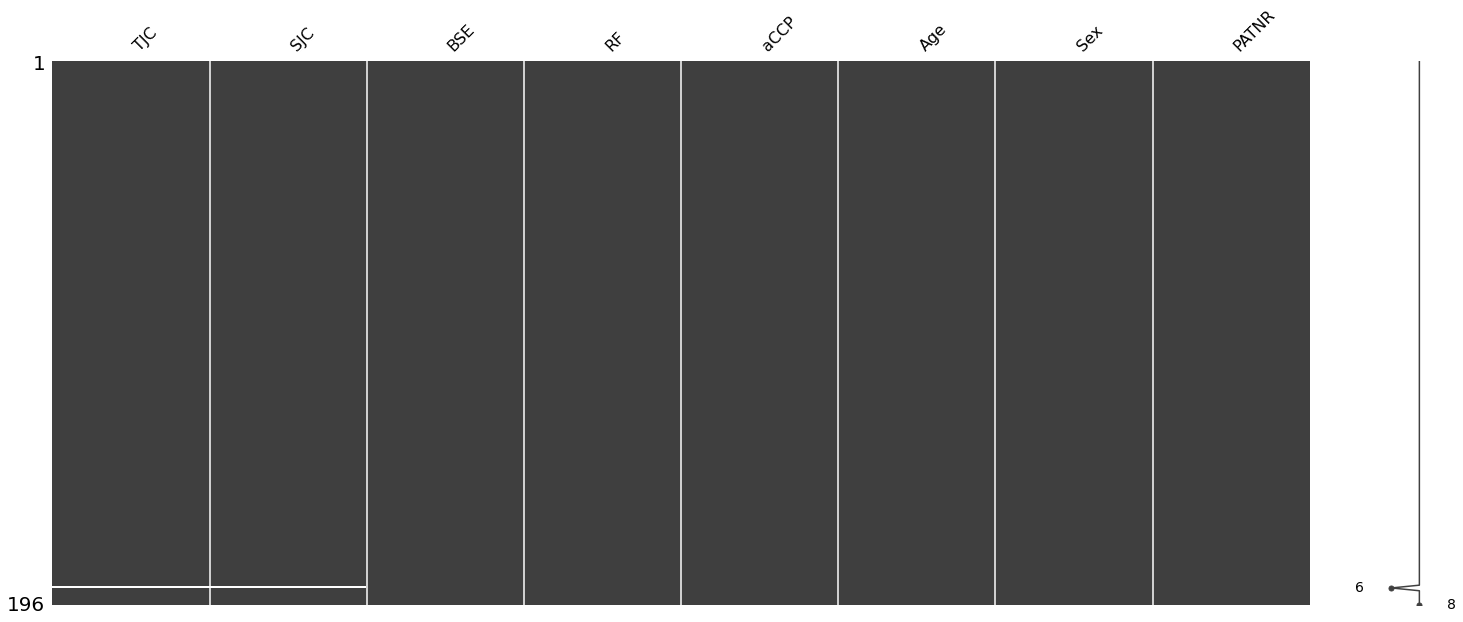

In [15]:
import missingno as msno

l_essential = ['TJC', 'SJC', 'BSE', 'RF', 'aCCP', 'Age', 'Sex', 'PATNR'] # 'Ht', 
    
%matplotlib inline
msno.matrix(df_danmark_num[l_essential]) # check if patients that miss variables across lines -> have aCCP / RF of 2df_lab_sc

## #2. Project new data

Load different custom env: 
conda activate /exports/reum/tdmaarseveen/envs/mmae/envs/ae_training/

### #2.1 Force same dimensions
We have less caterogical features in the replication set, thus we are required to reduce the dimensions. In order to create a shared latent space in the next step

In [61]:
import pandas as pd

l_num = ['BSE', 'Age'] # 'Ht', 
#l_num = ['Leuko', 'Ht', 'Hb', 'MCV', 'Trom', 'BSE', 'Age', 'PATNR']

# Variables from development set
df_numeric = pd.read_csv('/exports/reum/tdmaarseveen/RA_Clustering/new_data/5_clustering/df_lab_scaled_demographics.csv', sep=',')
df_numeric['PATNR'] = df_numeric['pseudoId']
df_numeric = df_numeric[l_num].copy()
df_categoric= pd.read_csv('/exports/reum/tdmaarseveen/RA_Clustering/new_data/5_clustering/df_categoric_wAge.csv', sep=',')
df_categoric['PATNR'] = df_categoric['pseudoId']
df_categoric = df_categoric[l_cat].copy()

l_num.append('PATNR')

# Variables from replication set
df_categoric_replication = pd.read_csv('Danmark/df_danmark_categoric_ohe.csv', sep='|')[l_cat]
df_numeric_replication = pd.read_csv('Danmark/Danmark_Lab_wide_scaled.csv', sep='|')[l_num]


# Select complete patients
l_essential = ['RF', 'aCCP', 'PATNR'] #  'Ht',
l_pat_repl = list(df_numeric_replication.dropna()['PATNR'].unique())

df_categoric_replication = df_categoric_replication[df_categoric_replication['PATNR'].isin(l_pat_repl)].reset_index(drop=True)
df_numeric_replication = df_numeric_replication[df_numeric_replication['PATNR'].isin(l_pat_repl)].reset_index(drop=True)

df_categoric_replication = df_categoric_replication.fillna(0)
df_numeric_replication = df_numeric_replication.fillna(0)

### Create metadata

In [62]:
df_numeric_raw = pd.read_csv('Danmark/Danmark_Lab_wide_unscaled.csv', sep='|')[l_num]

df_meta = pd.merge(df_categoric_replication, df_numeric_raw, left_on='PATNR', right_on='PATNR')
df_meta['pseudoId'] = df_meta['PATNR'] 

### create combined metadata

In [63]:
# import metadata of development set
metadata_RA = pd.read_csv('/exports/reum/tdmaarseveen/RA_Clustering/new_data/7_final/MMAE_clustering_270.csv', index_col=0) #  pd.read_csv('/exports/reum/tdmaarseveen/RA_Clustering/new_data/5_clustering/df_metadata.csv')
metadata_RA['Replication'] = 0
metadata_RA['PATNR'] = metadata_RA['pseudoId'].str[:-2] 

df_meta['Replication'] = 1
df_meta['pseudoId'] = df_meta['PATNR'].copy()

df_meta_full = pd.concat([df_meta, metadata_RA])
df_meta_full.reset_index(drop=True)
df_meta_full.to_csv('Danmark/Metadata_complete_Danmark.csv', sep='|', index=False)

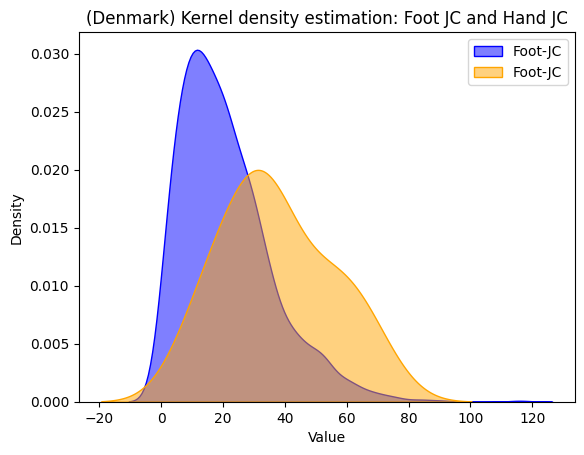

In [75]:
import seaborn as sns
df_meta_full = pd.read_csv('Danmark/Metadata_complete_Danmark.csv', sep='|')
#df_meta_full[df_meta_full['Replication']==1]['Age'].hist()

df_numeric = pd.read_csv('/exports/reum/tdmaarseveen/RA_Clustering/new_data/5_clustering/df_lab_raw_demographics.csv', sep=',')
#df_numeric['Age'].hist()



#plt.hist(df_meta_full[df_meta_full['Replication']==1]['Age'], bins=10, alpha=0.5, color='red', label='Danmark', density=True)
#plt.hist(df_numeric['Age'], bins=10, alpha=0.5, color='blue', label='Leiden', density=True)
FEET_JOINTS = [col for col in df_meta_full.columns if (('pip' in col and 'voet' in col) or 'mtp' in col or ('dip' in col and 'voet' in col) or ('IP' in col and 'voet' in col)) and 'positive' in col and 'hand' not in col]
HAND_JOINTS = [col for col in df_meta_full.columns if ('tarso' in col or 'pip' in col or 'mcp' in col or 'cmc' in col or 'dip' in col or 'IP' in col  or 'pols' in col) and 'positive' in col and 'voet' not in col]
JOINTS = [col for col in df_meta_full.columns if ('positive' in col)]


df_meta_full['JOINTS'] = df_meta_full[JOINTS].sum(axis=1)
df_meta_full['FEET-count'] = df_meta_full[FEET_JOINTS].sum(axis=1)
df_meta_full['HAND-count'] = df_meta_full[HAND_JOINTS].sum(axis=1)
df_meta_full['Feet-HAND-prev'] = df_meta_full[FEET_JOINTS].sum(axis=1) / df_meta_full[HAND_JOINTS].sum(axis=1)
#df_treat_new
df_meta_full['FEET-count'] 



# Plot Kernel Density Estimations (KDEs)
sns.kdeplot(df_meta_full[df_meta_full['Replication']==0]['JOINTS'], bw_adjust=1, fill=True, alpha=0.5, color='blue', label='Foot-JC')
sns.kdeplot(df_meta_full[df_meta_full['PATNR'].isin(d_remap_icelandic.values())]['JOINTS'], bw_adjust=1, fill=True, alpha=0.5, color='orange', label='Foot-JC')

# Add labels, legend, and title
plt.xlabel('Value')
plt.ylabel('Density')
plt.title('(Denmark) Kernel density estimation: Foot JC and Hand JC')
plt.legend()

plt.show()

### #2.2 learn shared product space

In [64]:
import os, platform, subprocess, re

def get_processor_name():
    if platform.system() == "Windows":
        return platform.processor()
    elif platform.system() == "Darwin":
        os.environ['PATH'] = os.environ['PATH'] + os.pathsep + '/usr/sbin'
        command ="sysctl -n machdep.cpu.brand_string"
        return subprocess.check_output(command).strip()
    elif platform.system() == "Linux":
        command = "cat /proc/cpuinfo"
        all_info = subprocess.check_output(command, shell=True).decode().strip()
        for line in all_info.split("\n"):
            if "model name" in line:
                return re.sub( ".*model name.*:", "", line,1)
    return ""

get_processor_name()

' Intel(R) Xeon(R) CPU E5-2690 v3 @ 2.60GHz'

In [65]:
import time
import numpy as np
from mmae.multimodal_autoencoder import MultimodalAutoencoder # MMAE
import tensorflow as tf


# Be aware: Remove features with zero variation!!


# Use pseudo labels

# Build the model on Original set

input_shapes = {'Categoric': df_categoric[l_cat[1:]].shape[1:], 'Numeric': df_numeric.shape[1:]} 
data = [np.array(df_categoric[l_cat[1:]].values), np.array(df_numeric.values)]

# Number of units of each layer of encoder network
hidden_dims = [128, 64, 8] # 16?
# Output activation functions for each modality
output_activations = ['sigmoid' , 'relu'] # , 'relu'
# Name of Keras optimizer
optimizer = 'adam'
# Loss functions corresponding to a noise model for each modality
loss = ['bernoulli_divergence', 'gaussian_divergence']

# Set seed
#tf.keras.utils.set_random_seed(1234)
tf.random.set_seed(1234567)

# Construct autoencoder network
autoencoder = MultimodalAutoencoder(input_shapes, hidden_dims,
                                    output_activations)
autoencoder.compile(optimizer, loss)


t0 = time.time()
# Train model where input and output are the same
history = autoencoder.fit(data, epochs=100) # validation_data=validation_data # or 5000

t1 = time.time()
print('Time to create product space: ' + str(t1-t0))


# Get Latent space of original data
z_filtered = autoencoder.encode(data)
 
#tf.keras.models.save_model()
# Save maui model state (that only uses variables also present in replication set)
#maui_model.save('/exports/reum/tdmaarseveen/RA_Clustering/models/replication_maui')
autoencoder.save('models/Danmark_MMAE')

# Save shared productspace (that only uses variables also present in replication set)
l_embedding = ['PATNR']

df_z = pd.DataFrame(z_filtered)
for ix, col in enumerate(df_z): # z-filtered might be row based
    df_z['LF%s' % ix] = df_z[ix].copy()
    l_embedding.append('LF%s' % ix)
 
metadata_RA = pd.read_csv('/exports/reum/tdmaarseveen/RA_Clustering/new_data/7_final/MMAE_clustering_270.csv', index_col=0)
df_z.insert(0, 'PATNR', metadata_RA['pseudoId'])
df_z = df_z[l_embedding].copy()
   
df_z[l_embedding].to_csv('/exports/reum/tdmaarseveen/RA_Clustering/results/embedding/NORDSTAR_embedding_Denmark.csv', index=False, sep=',')


i,dim: 0 128
i,dim: 1 64
i,dim: 2 8
Names MM: Tensor("concatenate_1_1/Identity:0", shape=(None, 269), dtype=float32)
L33: {'batch_input_shape': (None, 8), 'dtype': 'float32', 'sparse': False, 'ragged': False, 'name': 'representation'}
L33: {'name': 'decoding_1', 'trainable': True, 'dtype': 'float32', 'node_def': {'name': 'decoding_1', 'op': 'Identity', 'input': ['representation_2'], 'attr': {'T': {'type': 'DT_FLOAT'}}}, 'constants': {}}
L33: {'name': 'dense3_1', 'trainable': True, 'dtype': 'float32', 'units': 64, 'activation': 'relu', 'use_bias': True, 'kernel_initializer': {'class_name': 'GlorotUniform', 'config': {'seed': None}}, 'bias_initializer': {'class_name': 'Zeros', 'config': {}}, 'kernel_regularizer': None, 'bias_regularizer': None, 'activity_regularizer': None, 'kernel_constraint': None, 'bias_constraint': None}
L33: {'name': 'kernel2_2', 'trainable': True, 'dtype': 'float32', 'rate': 0.0, 'noise_shape': None, 'seed': None}
L33: {'name': 'dense3_0', 'trainable': True, 'dtype

44/44 [==============================] - 0s 2ms/step - loss: 0.5975 - Categoric_reconstruction_loss: 0.2128 - Numeric_reconstruction_loss: 0.3847
Epoch 37/100
44/44 [==============================] - 0s 2ms/step - loss: 0.5946 - Categoric_reconstruction_loss: 0.2122 - Numeric_reconstruction_loss: 0.3825
Epoch 38/100
44/44 [==============================] - 0s 2ms/step - loss: 0.5941 - Categoric_reconstruction_loss: 0.2116 - Numeric_reconstruction_loss: 0.3825
Epoch 39/100
44/44 [==============================] - 0s 2ms/step - loss: 0.5945 - Categoric_reconstruction_loss: 0.2111 - Numeric_reconstruction_loss: 0.3834
Epoch 40/100
44/44 [==============================] - 0s 2ms/step - loss: 0.5939 - Categoric_reconstruction_loss: 0.2107 - Numeric_reconstruction_loss: 0.3831
Epoch 41/100
44/44 [==============================] - 0s 2ms/step - loss: 0.5924 - Categoric_reconstruction_loss: 0.2103 - Numeric_reconstruction_loss: 0.3821
Epoch 42/100
44/44 [==============================] - 0s 2m

### #2.2 Project novel instances onto latent embedding


In [66]:
import sys
#sys.path.append(r'../../modules/parametric_tsne/')
#sys.path.append(r'../../modules/')
sys.path.append(r'../../../src/1_emr_scripts')
import Visualization as func
from sklearn.manifold import TSNE

# --------------------------------- Add new patients ---------------------------------------------
model=tf.keras.models.load_model('models/Danmark_MMAE', compile=False)

# Project new sample in product space


df_categoric_replication  = df_categoric_replication.fillna(0)
#z_patient = maui_model.transform({ 'Categorical': df_categoric_replication.T, 'Lab_numerical': df_numeric_replication.T})
lcat = [col for col in df_categoric_replication.columns if col not in ['PATNR']]
lnum = [col for col in df_numeric_replication.columns if col not in ['PATNR']]
data = [np.array(df_categoric_replication[lcat].values), np.array(df_numeric_replication[lnum].values)]

z_patient = model.encoder.predict(data, batch_size=256)
z_patient = pd.DataFrame(z_patient)

l_embedding = ['PATNR']
for ix, col in enumerate(z_patient): # z-filtered might be row based
    z_patient['LF%s' % ix] = z_patient[ix].copy()
    l_embedding.append('LF%s' % ix)

z_patient.insert(0, 'PATNR', df_meta['PATNR'])

# Add new patient to product space
df_z = df_z.append(z_patient[l_embedding], ignore_index = True)

# --------------------------------- Add new patients ---------------------------------------------

# Create interactive TSNE with metadata
X_embedded = TSNE(n_components=2, random_state=7062021).fit_transform(df_z[df_z.columns[1:]])


# Open metadata
df_imp = pd.read_csv('Danmark/Metadata_complete_Danmark.csv', sep='|')
df_imp['SJC'] =df_imp[[col for col in df_imp.columns if ('Zwelling_' in col and 'positive' in col)]].sum(axis=1)
df_imp['TJC'] =df_imp[[col for col in df_imp.columns if  ('Pijn_' in col and 'positive' in col)]].sum(axis=1)
df_imp['patnr'] = range(len(df_imp))


# Get more insight by visualizing the ratios
df_imp['Swollen ratio'] = df_imp['SJC'] / (df_imp['SJC']+df_imp['TJC'])
df_imp['Swollen ratio'] = df_imp['Swollen ratio'].fillna(0)

df_imp['Tender ratio'] = df_imp['TJC'] / (df_imp['SJC']+df_imp['TJC'])
df_imp['Tender ratio'] = df_imp['Tender ratio'].fillna(0)

df_imp['Big ratio'] = df_imp['Big joints'] / (df_imp['TJC']+df_imp['SJC'])
df_imp['Big ratio'] = df_imp['Big ratio'].fillna(0)

df_imp['Small ratio'] = df_imp['Small joints'] / (df_imp['TJC']+df_imp['SJC'])
df_imp['Small ratio'] = df_imp['Small ratio'].fillna(0)

df_imp['Symmetrical ratio'] = df_imp['Symmetrical joints'] / (df_imp['TJC']+df_imp['SJC'])
df_imp['Symmetrical ratio'] = df_imp['Symmetrical ratio'].fillna(0)

# write coordinates embedding
df_imp['coor_x'] = X_embedded[:, 0]
df_imp['coor_y'] = X_embedded[:, 1]

# update column
df_imp['PATNR'] = df_z['PATNR'].copy()

# Save embedding + projection
df_z.to_csv('/exports/reum/tdmaarseveen/RA_Clustering/results/embedding/Danmark_embedding_projections.csv', index=False, sep=',')

/tmp/ipykernel_109046/4119858849.py:31: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  df_z = df_z.append(z_patient[l_embedding], ignore_index = True)
/exports/reum/tdmaarseveen/envs/mmae/envs/ae_training/lib/python3.8/site-packages/sklearn/manifold/_t_sne.py:800: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
/exports/reum/tdmaarseveen/envs/mmae/envs/ae_training/lib/python3.8/site-packages/sklearn/manifold/_t_sne.py:810: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(


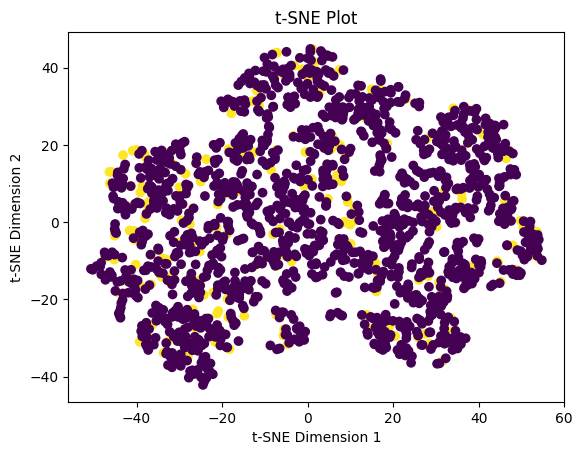

In [67]:
import matplotlib.pyplot as plt
# Plot t-SNE
plt.scatter(df_imp['coor_x'], df_imp['coor_y'], c= df_imp['Replication'])
plt.title('t-SNE Plot')
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.show()

In [68]:
l_cat = [col for col in df_categoric_replication.columns if col not in ['PATNR']]

# update column
df_imp['PATNR'] = df_z['PATNR'].astype(str).copy()
df_imp['Replication'] = df_imp['Replication'].astype(float)

#df_imp['Age_Early'] = df_imp['Age_Early'].fillna(0)
##df_imp['Age_Late'] =df_imp['Age_Late'].fillna(0)
df_imp = df_imp.fillna(0)

l_cat_spec = ['RF']
l_cat_spec.extend(l_cat_patnr)
l_cat_spec = l_cat_spec[:-3]
l_cat_spec.append('patnr')
l_cat_spec.append('Replication')
l_cat_spec.pop(-5)


# Save embedding + projection
df_z.to_csv('/exports/reum/tdmaarseveen/RA_Clustering/results/embedding/Danmark_embedding_projections.csv', index=False, sep=',')

# Important to start with RF -> (why i do not knwo)

func.visualize_umap_bokeh_na_2(X_embedded, df_imp[l_cat_spec],  l_cat_spec, l_binary=l_cat_spec, patient_id='patnr', cluster_id='RF', title='MMAE_UMAP2',  path='Danmark/Danmark_MMAE.html')

1583 1583
0 []

UMAP figure saved under location: TSNE/Baseline_MMAE_UMAP2.html


## #3 Classify novel instances (POODLE)

### #3.1 Initialize variables for patient assignment

In [69]:
from sklearn.metrics.pairwise import cosine_similarity

df_cluster = metadata_RA[['pseudoId','PhenoGraph_clusters']].copy()

# Construct patient similarity matrix from original set
sim_matrix = cosine_similarity(z_filtered.astype(np.float32))

# Specify columns for each modality (need to be present in both original & replication space)
d_input = {'cat' : list(df_categoric_replication[lcat].columns), 'num' : list(df_numeric_replication[lnum].columns)}

# Intialize list to save location of newly projected patients
z_new = []

# Define cluster
CLUSTER_LABEL = 'PhenoGraph_clusters'

# Initialize dataframe where we collect all predictors of interest for assigning patients to a cluster 
archetype_columns = ['weight_pval', 'weight_mean', 'weight_sd', 'cluster_mean_pat', 'cluster_sd_pat'] # + latent factors?
l_col = ['pseudoId', CLUSTER_LABEL]
for i in range(len(np.unique(df_cluster[CLUSTER_LABEL]))):
    l_col.extend(['%s_%s' % (col, i) for col in archetype_columns ])

df_characteristics = pd.DataFrame(columns=l_col)

### #3.2 Project the patients onto latent space and see how they are oriented

In [70]:
import sys
sys.path.append(r'/exports/reum/tdmaarseveen/Poodle')
from poodle import utils as pup
import importlib as imp
import numpy 
imp.reload(pup)
np.seterr('raise') # reveal potential floating point errors

# Bookmark identifier (use fake)
df_id = pd.DataFrame({'pseudoId' : ['id_' + str(i) for i in range(len(df_numeric_replication))]})

for ix, new_pat in enumerate(df_id['pseudoId']):
    # collect sample information
    new_pat = str(df_id.iloc[ix]['pseudoId'])
    sample_cat = df_categoric_replication[lcat].iloc[ix]
    sample_num = df_numeric_replication[lnum].iloc[ix]
    #sample =  sample_cat.append(sample_num)
    sample = pd.concat([sample_cat, sample_num], axis=0)
    sample.name = new_pat

    # create metadata
    df_meta = pup.getMetaDataPatient(df_cluster, list(df_cluster['pseudoId'].values), new_pat)
    
    l_orientation = [df_id.iloc[ix]['pseudoId'], -1]
    
    # What is the orientation of the patient compared to each cluster
    # In other words, which cluster has the largest gravity on the patient
    l_orientation.extend(pup.getOrientation(autoencoder, df_meta, pd.DataFrame(z_filtered), d_input, sample, sim_matrix=sim_matrix, cluster_label='PhenoGraph_clusters'))

    # Bookmark cluster characteristics
    df_characteristics.loc[len(df_characteristics)] = l_orientation
    
df_characteristics['pseudoId'] = df_id['pseudoId'].copy()
df_characteristics.to_csv('Danmark/ClusterCharacteristics_Projection_Danmark.csv', index=False, sep=',')
df_characteristics.head()

,pseudoId,PhenoGraph_clusters,weight_pval_0,weight_mean_0,weight_sd_0,cluster_mean_pat_0,cluster_sd_pat_0,weight_pval_1,weight_mean_1,weight_sd_1,...,weight_pval_2,weight_mean_2,weight_sd_2,cluster_mean_pat_2,cluster_sd_pat_2,weight_pval_3,weight_mean_3,weight_sd_3,cluster_mean_pat_3,cluster_sd_pat_3
0,id_0,-1,1.000000,0.896928,0.078554,0.920346,0.042216,1.000000,0.939387,0.043577,...,0.999667,0.927889,0.049681,0.935311,0.038559,0.999999,0.798699,0.137831,0.827409,0.093583
1,id_1,-1,0.000001,0.896928,0.078554,0.858107,0.058440,1.000000,0.939387,0.043577,...,0.000001,0.927889,0.049681,0.908280,0.051754,0.000001,0.798699,0.137831,0.749965,0.106210
2,id_2,-1,0.000001,0.896928,0.078554,0.744067,0.100392,0.000001,0.939387,0.043577,...,0.000001,0.927889,0.049681,0.708012,0.098374,0.000001,0.798699,0.137831,0.752343,0.136614
3,id_3,-1,1.000000,0.896928,0.078554,0.935108,0.049148,0.105084,0.939387,0.043577,...,1.000000,0.927889,0.049681,0.944407,0.034350,1.000000,0.798699,0.137831,0.870818,0.083657
4,id_4,-1,0.000001,0.896928,0.078554,0.875663,0.082281,0.000001,0.939387,0.043577,...,0.000001,0.927889,0.049681,0.868572,0.063296,0.917470,0.798699,0.137831,0.809314,0.124269


### #3.3 Build Poodle classifier

#### #3.3.1 Quantify orientation of original samples with respect to clusters

In [71]:
import pandas as pd
import numpy as np
from math import exp
from scipy.stats import ttest_ind
from scipy.spatial.distance import cosine# cosine minkowski
from sklearn.metrics.pairwise import cosine_similarity
import sys
sys.path.append(r'/exports/reum/tdmaarseveen/Poodle')
from poodle import utils as pup
#import importlib as imp
#imp.reload(pup)
CLUSTER_LABEL = 'PhenoGraph_clusters'
# Initialize similarity matrix
# We only need to calculate the pairwise similarities of the initial space 1 time
sim_matrix = cosine_similarity(z_filtered.astype(np.float32))

df_characteristics_original = pup.quantifySimilarity(df_cluster, sim_matrix, CLUSTER_LABEL = 'PhenoGraph_clusters')
    
# Bookmark cluster characteristics
df_characteristics_original['pseudoId'] = df_cluster['pseudoId'].copy()
df_characteristics_original[CLUSTER_LABEL] = df_cluster[CLUSTER_LABEL].copy()
df_characteristics_original.to_csv('Danmark/ClusterCharacteristics_Original.csv', index=False, sep=',')
df_characteristics_original.head()

,pseudoId,PhenoGraph_clusters,weight_pval_0,weight_mean_0,weight_sd_0,cluster_mean_pat_0,cluster_sd_pat_0,weight_pval_1,weight_mean_1,weight_sd_1,...,weight_pval_2,weight_mean_2,weight_sd_2,cluster_mean_pat_2,cluster_sd_pat_2,weight_pval_3,weight_mean_3,weight_sd_3,cluster_mean_pat_3,cluster_sd_pat_3
0,304828067_0,0,1.000000e+00,0.896764,0.078631,0.930634,0.050273,2.078822e-16,0.939387,0.043577,...,5.033452e-48,0.927889,0.049681,0.877095,0.052766,1.000000,0.798699,0.137831,0.847695,0.094317
1,304835496_0,1,3.596122e-09,0.896927,0.078554,0.877817,0.065599,9.993862e-01,0.939351,0.043590,...,2.248109e-52,0.927889,0.049681,0.864463,0.061919,0.000009,0.798699,0.137831,0.767724,0.115783
2,304837810_0,3,1.000000e+00,0.896927,0.078554,0.926267,0.050812,1.885351e-13,0.939387,0.043577,...,8.740209e-67,0.927889,0.049681,0.858640,0.056250,1.000000,0.798305,0.138056,0.851330,0.089140
3,304871478_0,3,2.680296e-90,0.896927,0.078554,0.770931,0.097800,1.448535e-192,0.939387,0.043577,...,3.161366e-149,0.927889,0.049681,0.650171,0.103841,0.000002,0.798955,0.137938,0.764617,0.117903
4,304835849_0,0,9.999773e-01,0.896855,0.078571,0.911797,0.073475,9.078921e-86,0.939387,0.043577,...,9.431498e-52,0.927889,0.049681,0.861067,0.065807,1.000000,0.798699,0.137831,0.865814,0.092806


#### #3.3.2 Optimize weights with simple classifier

TRAIN: [222 223 224 225 226 227 228 229 230 231] TEST: [0 1 2 3 4 5 6 7 8 9]
[12:56:48] WARNING: ../src/learner.cc:767: 
Parameters: { "n_trees" } are not used.

TRAIN: [0 1 2 3 4 5 6 7 8 9] TEST: [222 223 224 225 226 227 228 229 230 231]
[12:56:48] WARNING: ../src/learner.cc:767: 
Parameters: { "n_trees" } are not used.

TRAIN: [0 1 2 3 4 5 6 7 8 9] TEST: [444 445 446 447 448 449 450 451 452 453]
[12:56:48] WARNING: ../src/learner.cc:767: 
Parameters: { "n_trees" } are not used.

TRAIN: [0 1 2 3 4 5 6 7 8 9] TEST: [666 667 668 669 670 671 672 673 674 675]
[12:56:48] WARNING: ../src/learner.cc:767: 
Parameters: { "n_trees" } are not used.

TRAIN: [0 1 2 3 4 5 6 7 8 9] TEST: [888 889 890 891 892 893 894 895 896 897]
[12:56:49] WARNING: ../src/learner.cc:767: 
Parameters: { "n_trees" } are not used.



Text(0.5, 1.0, 'Confusion matrix for the Poodle labeler (XGB) on trainingsset (ACC: 1.00)')

<Figure size 640x480 with 0 Axes>

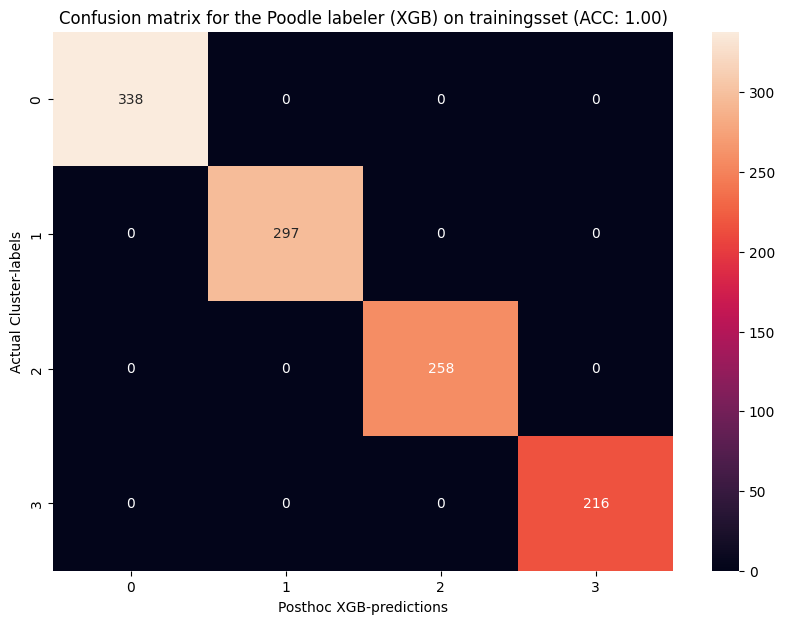

In [72]:
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
import xgboost as xgb
import matplotlib.pyplot as plt
import time
import seaborn as sn
from sklearn.metrics import confusion_matrix, plot_confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.metrics import f1_score
from sklearn.preprocessing import StandardScaler

df_train, df_test = train_test_split(df_characteristics_original, test_size=0.2,  random_state=28072022) # stratify=df_characteristics['PhenoGraph_clusters'],

target = 'PhenoGraph_clusters'

cols_data = [x for x in list(df_train.columns) if x not in ['pseudoId', target]] #   'Sex', 'Age', 

X = df_train[cols_data].values
y = df_train[target]

# Apply 5 fold CV
kf = KFold(n_splits=5) # 
iteration = 0
y_pred = []
y_proba = []

for train_index, test_index in kf.split(X):
    print("TRAIN:", train_index[:10], "TEST:", test_index[:10])
    X_train, X_test = pd.DataFrame(X).loc[train_index], pd.DataFrame(X).loc[test_index]
    y_train, y_test = np.take(y, np.array(train_index)),np.take(y, np.array(test_index))#.values  # .values

    # Z-score scaling
    scaler = StandardScaler().fit(X_train)
    X_train= scaler.transform(X_train)
    X_test = scaler.transform(X_test)

    # Model is an XGBClassifier
    n_trees = 50
    dmat_train = xgb.DMatrix(X_train, y_train)
    dmat_test = xgb.DMatrix(X_test, y_test)
    
    t0 = time.time()
    xgb_clf = xgb.XGBClassifier(objective='multi:softmax', eval_metric='merror', num_class=len(y.unique()), n_trees=50)
    xgb_clf = xgb_clf.fit(X_train, y_train)

    
    t1 = time.time()
    #print('Time for Training XGB model %s: %s' % (str(iteration+1), str(t1-t0)))
    iteration += 1
    
    # Create a confusion matrix over all data!
    #y_pred.extend(bst.predict(dmat_test))
    y_proba.extend(xgb_clf.predict_proba(X_test))
    y_pred.extend(xgb_clf.predict(X_test))
    
fig = plt.figure()
cm = confusion_matrix(y, y_pred)
accuracy = accuracy_score(y, y_pred)


df_cm = pd.DataFrame(cm, index = list(range(len(y.unique()))),
                  columns = list(range(len(y.unique()))))
plt.figure(figsize = (10,7))
sn.heatmap(df_cm, annot=True, fmt='g')
plt.xlabel("Posthoc XGB-predictions")
plt.ylabel("Actual Cluster-labels")
plt.title('Confusion matrix for the Poodle labeler (XGB) on trainingsset (ACC: %.2f)' % (accuracy))

#### #3.3.3 Show performance on hold-out test set

Text(0.5, 1.0, 'Confusion matrix for the Poodle labeler (XGB) in independent test set (ACC: 1.00)')

<Figure size 640x480 with 0 Axes>

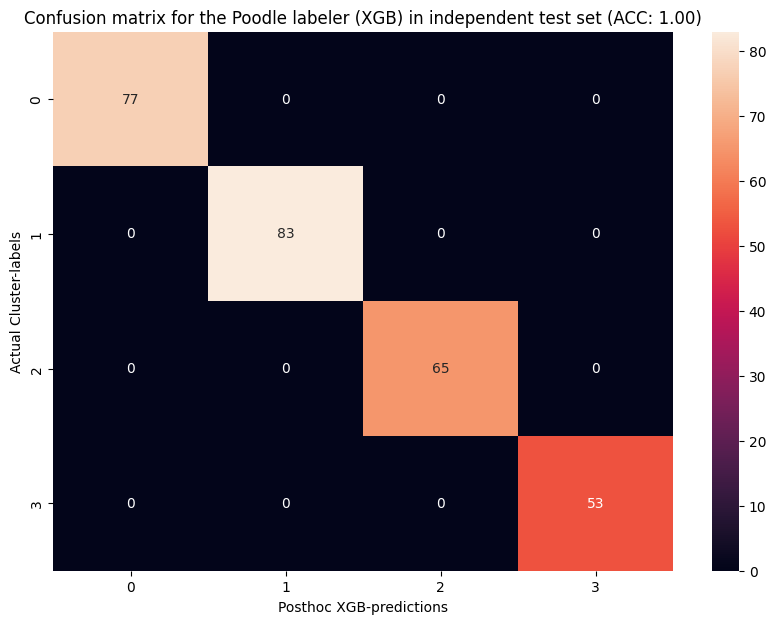

In [73]:
X_test_final = df_test[cols_data].values
y_test_final = df_test[target]

# Z-score scaling
#scaler = StandardScaler().fit(X_test)
X_test_final = scaler.transform(X_test_final)
y_pred_final = xgb_clf.predict(X_test_final)


fig = plt.figure()
cm = confusion_matrix(y_test_final, y_pred_final)
accuracy = accuracy_score(y_test_final, y_pred_final)


df_cm = pd.DataFrame(cm, index = list(range(len(y_test_final.unique()))),
                  columns = list(range(len(y_test_final.unique()))))
plt.figure(figsize = (10,7))
sn.heatmap(df_cm, annot=True, fmt='g')
plt.xlabel("Posthoc XGB-predictions")
plt.ylabel("Actual Cluster-labels")
plt.title('Confusion matrix for the Poodle labeler (XGB) in independent test set (ACC: %.2f)' % (accuracy))

#### #3.3.4 Compare to dummy classifier

Text(0.5, 1.0, 'Confusion matrix for the Dummy labeler (XGB) in independent test set (ACC: 0.53)')

<Figure size 640x480 with 0 Axes>

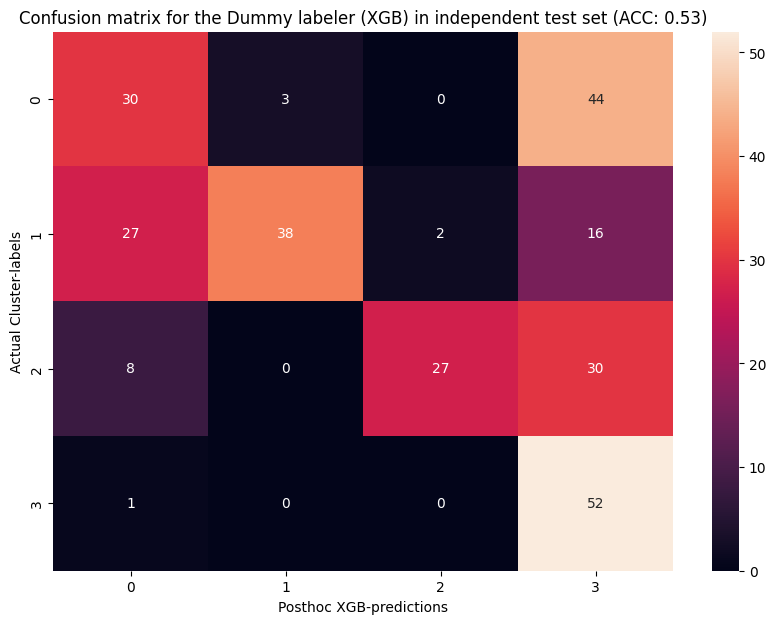

In [74]:
import numpy as np
import seaborn as sn
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, plot_confusion_matrix
from sklearn.metrics import accuracy_score

def dummyLabeler(X):
    return np.argmax(X) # largest p

target = 'PhenoGraph_clusters'

X = df_test[[col for col in df_test.columns if 'weight_pval' in col]].copy()
y = df_test[target]

y_pred = []

for ix in range(len(X)): # loop through patients
    y_pred.append(dummyLabeler(X.iloc[ix]))

fig = plt.figure()
cm = confusion_matrix(y, y_pred)
accuracy = accuracy_score(y, y_pred)

df_cm = pd.DataFrame(cm, index = list(range(len(y.unique()))),
                  columns = list(range(len(y.unique()))))
plt.figure(figsize = (10,7))
sn.heatmap(df_cm, annot=True, fmt='g')
plt.xlabel("Posthoc XGB-predictions")
plt.ylabel("Actual Cluster-labels")
plt.title('Confusion matrix for the Dummy labeler (XGB) in independent test set (ACC: %.2f)' % (accuracy))

#### #3.3.5 Train final model on all labeled data & Save model

In [75]:
from sklearn.model_selection import KFold
import xgboost as xgb
import matplotlib.pyplot as plt

import time
import seaborn as sn
from sklearn.metrics import confusion_matrix, plot_confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.metrics import f1_score
from sklearn.preprocessing import StandardScaler
from pickle import dump

X_all = df_characteristics_original[cols_data]
y_all = df_characteristics_original[CLUSTER_LABEL]

scaler = StandardScaler().fit(X_all)

X_all = scaler.transform(X_all)

dmat_train = xgb.DMatrix(X_all, y_all)

t0 = time.time()
bst  = xgb.train({'objective': 'multi:softmax',  'eval_metric':'merror', 'num_class':len(y.unique())}, dmat_train, # 'num_class':len(y.unique())
                    n_trees, evals=[(dmat_train, "train")]) # "tree_method": "gpu_hist", 'gamma': 8, , (dmat_test, "test")
t1 = time.time()

# save poodle labeler
bst.save_model("models/Danmark_poodle/xgb_model.json")

# save scaler
dump(scaler, open('models/Danmark_poodle/scaler.pkl', 'wb'))


[0]	train-merror:0.00000
[1]	train-merror:0.00000
[2]	train-merror:0.00000
[3]	train-merror:0.00000
[4]	train-merror:0.00000
[5]	train-merror:0.00000
[6]	train-merror:0.00000
[7]	train-merror:0.00000
[8]	train-merror:0.00000
[9]	train-merror:0.00000
[10]	train-merror:0.00000
[11]	train-merror:0.00000
[12]	train-merror:0.00000
[13]	train-merror:0.00000
[14]	train-merror:0.00000
[15]	train-merror:0.00000
[16]	train-merror:0.00000
[17]	train-merror:0.00000
[18]	train-merror:0.00000
[19]	train-merror:0.00000
[20]	train-merror:0.00000
[21]	train-merror:0.00000
[22]	train-merror:0.00000
[23]	train-merror:0.00000
[24]	train-merror:0.00000
[25]	train-merror:0.00000
[26]	train-merror:0.00000
[27]	train-merror:0.00000
[28]	train-merror:0.00000
[29]	train-merror:0.00000
[30]	train-merror:0.00000
[31]	train-merror:0.00000
[32]	train-merror:0.00000
[33]	train-merror:0.00000
[34]	train-merror:0.00000
[35]	train-merror:0.00000
[36]	train-merror:0.00000
[37]	train-merror:0.00000
[38]	train-merror:0.00

### #3.4 Use POODLE to cluster new instances

In [76]:
import sys
sys.path.append(r'../')
from poodle import utils as pup
import pandas as pd
from pickle import load

df_new = pd.read_csv('Danmark/ClusterCharacteristics_Projection_Danmark.csv', sep=',')

# Define input columns
target = 'PhenoGraph_clusters'
cols_data = [x for x in list(df_new.columns) if x not in ['pseudoId', target]]

# Classify patients
X_replication = df_new[cols_data]#.

# load the scaler
scaler = load(open('models/Danmark_poodle/scaler.pkl', 'rb'))
#X_replication = scaler.transform(X_replication)

df_new['PhenoGraph_clusters'] = pup.classifyPatient(X_replication, path="models/Danmark_poodle/")
df_new.to_csv('Danmark/ClusterAssignment_Danmark.csv', index=False, sep=',')
df_new.head()

,pseudoId,PhenoGraph_clusters,weight_pval_0,weight_mean_0,weight_sd_0,cluster_mean_pat_0,cluster_sd_pat_0,weight_pval_1,weight_mean_1,weight_sd_1,...,weight_pval_2,weight_mean_2,weight_sd_2,cluster_mean_pat_2,cluster_sd_pat_2,weight_pval_3,weight_mean_3,weight_sd_3,cluster_mean_pat_3,cluster_sd_pat_3
0,id_0,1.0,1.000000,0.896928,0.078554,0.920346,0.042216,1.000000,0.939387,0.043577,...,0.999667,0.927889,0.049681,0.935311,0.038559,0.999999,0.798699,0.137831,0.827409,0.093583
1,id_1,1.0,0.000001,0.896928,0.078554,0.858107,0.058440,1.000000,0.939387,0.043577,...,0.000001,0.927889,0.049681,0.908280,0.051754,0.000001,0.798699,0.137831,0.749965,0.106210
2,id_2,3.0,0.000001,0.896928,0.078554,0.744067,0.100392,0.000001,0.939387,0.043577,...,0.000001,0.927889,0.049681,0.708012,0.098374,0.000001,0.798699,0.137831,0.752343,0.136614
3,id_3,1.0,1.000000,0.896928,0.078554,0.935108,0.049148,0.105084,0.939387,0.043577,...,1.000000,0.927889,0.049681,0.944407,0.034350,1.000000,0.798699,0.137831,0.870818,0.083657
4,id_4,3.0,0.000001,0.896928,0.078554,0.875663,0.082281,0.000001,0.939387,0.043577,...,0.000001,0.927889,0.049681,0.868572,0.063296,0.917470,0.798699,0.137831,0.809314,0.124269


In [1]:
import pandas as pd
df_new = pd.read_csv('Danmark/ClusterAssignment_Danmark.csv', sep=',')
metadata_RA = pd.read_csv('/exports/reum/tdmaarseveen/RA_Clustering/new_data/7_final/MMAE_clustering_270.csv', index_col=0)

# Original clustering information (same samples as development set)
df_cluster = metadata_RA[['pseudoId', 'PhenoGraph_clusters']].copy()

Spatial variance in replication set: 	C1= 34; C2= 75; C3= 54; C4= 33
Spatial variance in original set: 	C1= 415; C2= 380; C3= 323; C4= 269


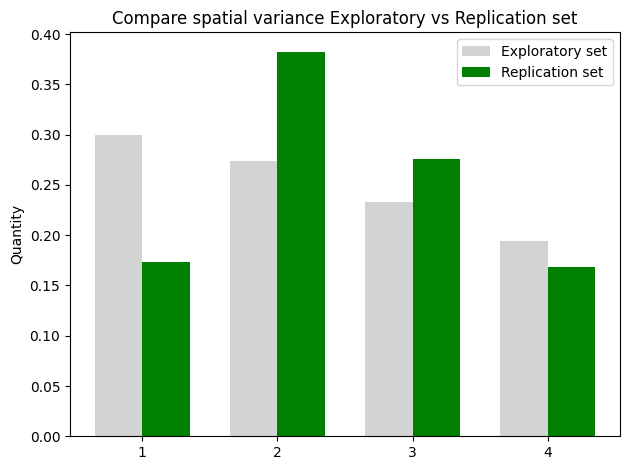

In [2]:
from collections import Counter
import sys
sys.path.append(r'/exports/reum/tdmaarseveen/Poodle')
from poodle import visualization as viz

c = Counter(df_new['PhenoGraph_clusters'])
l_new = [c[ix]/sum(c.values()) for ix in range(0,len(c))]
print('Spatial variance in replication set: \tC' + '; C'.join([str(ix+1) + '= ' + str(c[ix]) for ix in range(0,len(c))]))
c = Counter(df_cluster['PhenoGraph_clusters'])
l_old = [c[ix]/sum(c.values()) for ix in range(0,len(c))]
print('Spatial variance in original set: \tC' + '; C'.join([str(ix+1) + '= ' + str(c[ix]) for ix in range(0,len(c))]))

viz.plotSpatialVariation(l_new, l_old)

## Visualize joint involvement

In [3]:
import importlib as imp
import sys
sys.path.append(r'../../../src/1_emr_scripts')
import MannequinFunctions as func
imp.reload(func)
import matplotlib.pyplot as plt
import pandas as pd

(-0.5, 1452.5, 1799.5, -0.5)

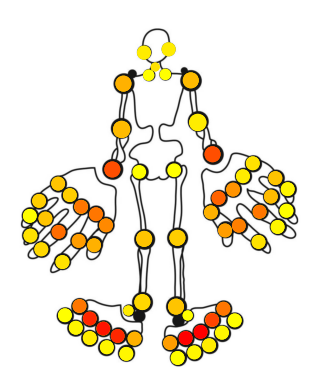

In [4]:
CLUSTER =0
CATEGORY = 'Pijn' # 'Zwelling'
# Import mannequin information
df_man = pd.read_csv('Danmark/Metadata_complete_Danmark.csv', sep='|') 
df_man = df_man[df_man['Replication']==1].copy()
df_man['PhenoGraph_clusters'] = df_new['PhenoGraph_clusters'].copy()
df_cluster['PATNR']=df_cluster['pseudoId'].copy()
l_pat = set(df_man[df_man['PhenoGraph_clusters']==CLUSTER]['PATNR'])
df_sub = df_man[df_man['PATNR'].isin(l_pat)].copy()

#create scatterplot (toDo: for both big & small joints)
#l_col = [col for col in df_sub.columns if col not in ['pseudoId', 'patnr','FirstConsult', 'PATNR']]
l_mannequin = [col for col in df_man.columns if ((('Zwelling_' in col or 'Pijn_' in col)) and 'positive' in col)]
l_col = [col for col in l_mannequin] # if CATEGORY in col
df_plot = pd.DataFrame(df_sub[l_col].mean().T)
df_plot= df_plot.reset_index()
df_plot.columns = ['feature', 'value']
df_plot['x'], df_plot['y'], df_plot['s'] = zip(*df_plot['feature'].apply(lambda x : func.get_mannequin_coord(x)))
df_plot['s'] = df_plot['s'] #* df_plot['value']

# Visualize gestalt
im = plt.imread('../../../figures/2_processing/Mannequin_large_old.jpg')
implot = plt.imshow(im)
plt.scatter(df_plot.x, df_plot.y, s=df_plot.s, c=df_plot.value, cmap='autumn_r')
fig = plt.gcf()
fig.set_dpi(100)
#plt.text(450, 1, r'Cluster %s' % str(CLUSTER+1), fontsize=15)
plt.axis('off')

### #3.6 Visualize Learned embedding

In [81]:
import sys
sys.path.append(r'../')
sys.path.append(r'/exports/reum/tdmaarseveen/Poodle')
from poodle import utils as pup
import pandas as pd
import numpy as np

df_z = pd.read_csv('/exports/reum/tdmaarseveen/RA_Clustering/results/embedding/Danmark_embedding_projections.csv', sep=',')
l_embedding = [col for col in df_z.columns]

# Variables from replication set
df_projection = pd.read_csv('Danmark/ClusterAssignment_Danmark.csv', sep=',')

# Select complete patients
#l_essential = ['SJC', 'Leuko', 'Hb', 'MCV', 'Trom',  'BSE', 'RF', 'aCCP', 'Age', 'Sex', 'PATNR']
#df_meta = pd.read_csv('/exports/reum/tdmaarseveen/RA_Clustering/new_data/offshoots/BeST/metadata_best.csv', sep='|')
#l_pat_repl = list(df_meta[l_essential].dropna()['PATNR'].unique())

# import metadata of SyG replication set
metadata_rep = pd.read_csv('Danmark/Metadata_complete_Danmark.csv', sep='|')
metadata_rep = metadata_rep[metadata_rep['Replication']==1].copy()
metadata_rep = metadata_rep.reset_index(drop=True)

# add cluster info for projected patietns
metadata_rep['PhenoGraph_clusters'] = df_projection['PhenoGraph_clusters'].copy() # len(metadata['PhenoGraph_clusters'].unique())+1

# import metadata of development set
metadata_RA = pd.read_csv('/exports/reum/tdmaarseveen/RA_Clustering/new_data/7_final/MMAE_clustering_270.csv', index_col=0) #  pd.read_csv('/exports/reum/tdmaarseveen/RA_Clustering/new_data/5_clustering/df_metadata.csv')
metadata_RA['Replication'] = 0

# Combine both metadatas
metadata = metadata_RA.append(metadata_rep, ignore_index = True)

# Add projected patients to original set
l_latent = [col for col in l_embedding if col not in ['pseudoId', 'PATNR']]

print('BEFORE: total samples for tsne: ', len(metadata_RA))
metadata_total, z_total = pup.add_projected_patients(metadata_RA, pd.DataFrame(z_filtered, columns=l_latent), metadata_rep, z_patient[l_latent]) # ix = 
print('After: total samples for tsne: ', len(metadata_total))

BEFORE: total samples for tsne:  1387
After: total samples for tsne:  1583


/tmp/ipykernel_109046/4079380179.py:32: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  metadata = metadata_RA.append(metadata_rep, ignore_index = True)


In [82]:
metadata_total.to_csv('Danmark/Danmark_Complete_META.csv', sep=';', index=None)

In [83]:
from umap.parametric_umap import ParametricUMAP
import importlib as imp

SEED = 20230409

embedder = ParametricUMAP(random_state=SEED)
embedding = embedder.fit_transform(z_filtered)
pup.plot_tsne(embedding, group_id=metadata_RA['PhenoGraph_clusters'], path='Danmark/umap_original_Danmark.png')

# save parametric UMAP
embedder.save('../../models/umap/umap_mapping_Danmark')

/exports/reum/tdmaarseveen/envs/mmae/envs/ae_training/lib/python3.8/site-packages/umap/parametric_umap.py:269: UserWarning: Data should be scaled to the range 0-1 for cross-entropy reconstruction loss.
  warn(


Epoch 1/10
15/15 [==============================] - 1s 36ms/step - loss: 0.5040
Epoch 2/10
15/15 [==============================] - 1s 36ms/step - loss: 0.3046
Epoch 3/10
15/15 [==============================] - 1s 36ms/step - loss: 0.2956
Epoch 4/10
15/15 [==============================] - 1s 36ms/step - loss: 0.2897
Epoch 5/10
15/15 [==============================] - 1s 36ms/step - loss: 0.2883
Epoch 6/10
15/15 [==============================] - 1s 36ms/step - loss: 0.2851
Epoch 7/10
15/15 [==============================] - 1s 36ms/step - loss: 0.2854
Epoch 8/10
15/15 [==============================] - 1s 36ms/step - loss: 0.2878
Epoch 9/10
15/15 [==============================] - 1s 36ms/step - loss: 0.2856
Epoch 10/10
15/15 [==============================] - 1s 36ms/step - loss: 0.2840
INFO:tensorflow:Assets written to: ../../models/umap/umap_mapping_Danmark/encoder/assets
Keras encoder model saved to ../../models/umap/umap_mapping_Danmark/encoder
INFO:tensorflow:Assets written to:

#### #3.6.2 Project both original and replication samples

In [84]:
# Project replication data onto tSNE
fit2 = embedder.transform(z_total.values)

# Plot Umap as 2d image
pup.plot_tsne(fit2, group_id=metadata_total['Replication'], path='Danmark/umap_replication_projected_Danmark.png')


## Create cluster table 

In [76]:
import pandas as pd
metadata_total = pd.read_csv('Danmark/Danmark_Complete_META.csv', sep=';')
extra_meta = pd.read_csv('Leiden_20240401.csv', sep=';')

df_subset = metadata_total[metadata_total['Replication']==1].reset_index(drop=True)# 'DAS28 (median+-IQR)',

df_subset = df_subset[df_subset['PATNR'].isin(d_remap_icelandic.values())]

# Drop columns with only missing values
df_subset = df_subset.dropna(axis=1, how='all')
df_full = pd.merge(df_subset, extra_meta, left_on='PATNR', right_on='SubjectId')
df_full = df_full.drop_duplicates(subset='SubjectId', keep='first')

In [77]:
import numpy as np

def IQR(data):
    # First quartile (Q1)
    Q1 = np.percentile(data, 25, interpolation = 'midpoint')

    # Third quartile (Q3)
    Q3 = np.percentile(data, 75, interpolation = 'midpoint')
   
    # Interquaritle range (IQR)
    iqr = Q3 - Q1
    return [Q1, Q3]

df_summary = pd.DataFrame(columns=['cluster', 'N', 'Sex, F [n(%)]','Age (median+-IQR)', 'RF [n(%)]', 'ACPA [n(%)]', 'CRP (median+-IQR)', 'DAS28 (median+-IQR)', 'SJC (median+-IQR)', 'TJC (median+-IQR)', 'RF_na [n(%)]','ACPA_na [n(%)]', 'CRP_na [n(%)]' , 'Mannequin_na [n(%)]']) #TreatSwitch [n(%)]', 

#df_subset = metadata_total[metadata_total['Replication']==1].reset_index(drop=True)# 'DAS28 (median+-IQR)',
#df_subset['symptomDuration'] = df_subset['symptomDuration']*7 # give symptom duration in days

def generate_baseline_ref(df_baseline, name = 'All', frac=''):
    if frac != '' :
        frac = '(' + frac + ')'
    return [name, '%.0f %s' % (len(df_baseline), frac), 
     '%.0f (%.1f)' % (np.sum(df_baseline['Sex']), np.mean(df_baseline['Sex']) * 100), 
     '%.1f (%.1f-%.1f)' % (np.median(df_baseline[~df_baseline['Age'].isna()]['Age']), IQR(df_baseline[~df_baseline['Age'].isna()]['Age'])[0], IQR(df_baseline[~df_baseline['Age'].isna()]['Age'])[1]),
     '%.1f (%.1f)' % (np.sum(df_baseline[~df_baseline['RF'].isna()]['RF']), np.mean(df_baseline[~df_baseline['RF'].isna()]['RF']) * 100), 
     '%.1f (%.1f)' % (np.sum(df_baseline[~df_baseline['aCCP'].isna()]['aCCP']), np.mean(df_baseline[~df_baseline['aCCP'].isna()]['aCCP']) * 100), 
       
     '%.1f (%.1f-%.1f)' % (np.median(df_baseline[~df_baseline['ANCRPVAL'].isna()]['ANCRPVAL']), IQR(df_baseline[~df_baseline['ANCRPVAL'].isna()]['ANCRPVAL'])[0], IQR(df_baseline[~df_baseline['ANCRPVAL'].isna()]['ANCRPVAL'])[1]),
     '%.1f (%.1f-%.1f)' % (np.median(df_baseline[~df_baseline['CALC_DAS28'].isna()]['CALC_DAS28']), IQR(df_baseline[~df_baseline['CALC_DAS28'].isna()]['CALC_DAS28'])[0], IQR(df_baseline[~df_baseline['CALC_DAS28'].isna()]['CALC_DAS28'])[1]),
     '%.1f (%.1f-%.1f)' % (np.median(df_baseline[~df_baseline['SJC'].isna()]['SJC']), IQR(df_baseline[~df_baseline['SJC'].isna()]['SJC'])[0], IQR(df_baseline[~df_baseline['SJC'].isna()]['SJC'])[1]),
     '%.1f (%.1f-%.1f)' % (np.median(df_baseline[~df_baseline['TJC'].isna()]['TJC']), IQR(df_baseline[~df_baseline['TJC'].isna()]['TJC'])[0], IQR(df_baseline[~df_baseline['TJC'].isna()]['TJC'])[1]),
     
     #'%.1f (%.1f-%.1f)' % (np.median(df_baseline[~df_baseline['symptomDuration'].isna()]['symptomDuration']), IQR(df_baseline[~df_baseline['symptomDuration'].isna()]['symptomDuration'])[0], IQR(df_baseline[~df_baseline['symptomDuration'].isna()]['symptomDuration'])[1]),
     '%.0f (%.1f)' % (len(df_baseline[df_baseline['RF'].isna()]), (len(df_baseline[df_baseline['RF'].isna()])/len(df_baseline))*100), '%.0f (%.1f)' % (len(df_baseline[df_baseline['aCCP'].isna()]), (len(df_baseline[df_baseline['aCCP'].isna()])/len(df_baseline))*100),
     '%.0f (%.1f)' % (len(df_baseline[df_baseline['ANCRPVAL'].isna()]), (len(df_baseline[df_baseline['ANCRPVAL'].isna()])/len(df_baseline))*100),
     '%.0f (%.1f)' % (len(df_baseline[df_baseline['SJC'].isna()]), (len(df_baseline[df_baseline['SJC'].isna()])/len(df_baseline))*100)
     
    ]
#df_summary.loc[0] = generate_baseline_ref(df_full, 'All')

for i in range(len(df_full['PhenoGraph_clusters'].unique())):
    df_summary.loc[i] = generate_baseline_ref(df_full[df_full['PhenoGraph_clusters']==i], 'Cluster %s' % str(i+1))

df_summary = df_summary.reset_index(drop=True)
df_summary.T

,0,1,2,3
cluster,Cluster 1,Cluster 2,Cluster 3,Cluster 4
N,1,4,4,7
"Sex, F [n(%)]",1 (100.0),3 (75.0),3 (75.0),4 (57.1)
Age (median+-IQR),52.0 (52.0-52.0),59.0 (42.0-66.0),35.0 (29.5-48.0),55.0 (53.5-62.5)
RF [n(%)],1.0 (100.0),1.0 (25.0),3.0 (75.0),3.0 (42.9)
ACPA [n(%)],1.0 (100.0),2.0 (50.0),3.0 (75.0),4.0 (57.1)
CRP (median+-IQR),15.0 (15.0-15.0),35.5 (17.5-52.0),8.0 (3.5-15.5),21.0 (6.0-47.5)
DAS28 (median+-IQR),5.5 (5.5-5.5),5.0 (4.1-6.0),5.3 (4.6-6.0),6.1 (5.5-7.1)
SJC (median+-IQR),22.0 (22.0-22.0),13.0 (12.0-13.5),14.0 (9.0-19.5),24.0 (22.5-28.0)
TJC (median+-IQR),16.0 (16.0-16.0),8.0 (2.5-16.5),16.5 (11.5-22.0),30.0 (24.5-39.0)


In [80]:
df_summary = pd.DataFrame(columns=['cluster', 'N', 'Sex, F [n(%)]','Age (median+-IQR)', 'RF [n(%)]', 'ACPA [n(%)]', 'CRP (median+-IQR)', 'DAS28 (median+-IQR)', 'SJC (median+-IQR)', 'TJC (median+-IQR)', 'RF_na [n(%)]','ACPA_na [n(%)]', 'CRP_na [n(%)]' , 'Mannequin_na [n(%)]']) #TreatSwitch [n(%)]', 

#
df_summary.loc[0] =generate_baseline_ref(df_full, 'All')

df_summary = df_summary.reset_index(drop=True)
df_summary.T

,0
cluster,All
N,16
"Sex, F [n(%)]",11 (68.8)
Age (median+-IQR),55.0 (36.5-59.5)
RF [n(%)],8.0 (50.0)
ACPA [n(%)],10.0 (62.5)
CRP (median+-IQR),18.0 (5.5-41.0)
DAS28 (median+-IQR),5.7 (4.8-6.2)
SJC (median+-IQR),19.5 (13.0-23.5)
TJC (median+-IQR),20.0 (13.0-29.5)
